Problem 1: House Price Prediction using Gradient Descent

# **Dataset:**

House Prices Dataset (Kaggle)

Tasks

Load the dataset using Pandas.

Select one feature (e.g., area) and the target variable (price). And convert them to numpy array

Implement the Mean Squared Error (MSE) Cost Function manually.

Calculate the initial cost using random values of slope and intercept.

Apply Gradient Descent from scratch.

Train for 1000 iterations.

Plot:

Iteration vs Cost

Actual vs Predicted Values

Report the final learned parameters.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt




In [3]:
df=pd.read_csv('Housing.csv')
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


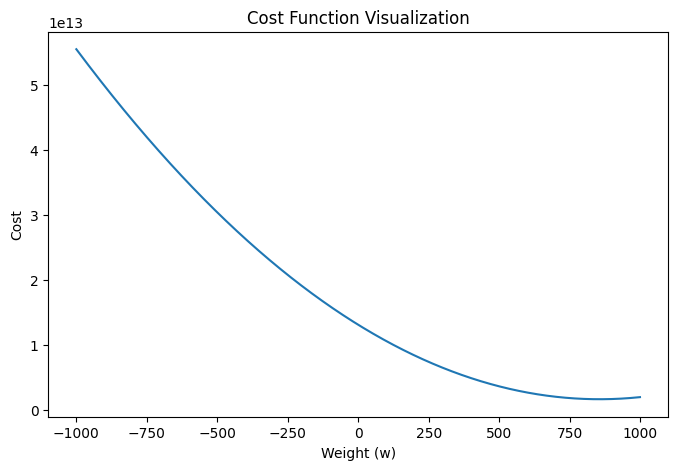

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load Dataset

df = pd.read_csv("Housing.csv")

X = df["area"].values
Y = df["price"].values



# Cost Function


def compute_cost(X, Y, w, b):

    m = X.shape[0]
    cost = 0.0

    for i in range(m):

        prediction = w * X[i] + b
        error = prediction - Y[i]

        cost = cost + error**2

    return cost / (2 * m)


# Gradient Calculation


def calculate_gradient(X, Y, w, b):

    m = X.shape[0]

    dj_dw = 0.0
    dj_db = 0.0

    for i in range(m):

        prediction = w * X[i] + b
        error = prediction - Y[i]

        dj_dw = dj_dw + (error * X[i])
        dj_db = dj_db + error

    return dj_dw / m, dj_db / m


# Cost Function Visualization


w_range = []
cost_values = []

for i in range(-1000, 1000):

    cost_i = compute_cost(X, Y, w=i, b=0)

    w_range.append(i)
    cost_values.append(cost_i)

plt.figure(figsize=(8,5))

plt.plot(w_range, cost_values)

plt.xlabel("Weight (w)")
plt.ylabel("Cost")
plt.title("Cost Function Visualization")

plt.show()


Initial Cost = 13106916364659.266
Iteration 0: Cost = 7080823741993.8369, w = 267.2292, b = 0.0477
Iteration 100: Cost = 1673381895292.8865, w = 855.7099, b = 0.5041
Iteration 200: Cost = 1673381766153.4792, w = 855.7098, b = 0.8634
Iteration 300: Cost = 1673381637014.1155, w = 855.7098, b = 1.2228
Iteration 400: Cost = 1673381507874.7869, w = 855.7097, b = 1.5822
Iteration 500: Cost = 1673381378735.4978, w = 855.7096, b = 1.9415
Iteration 600: Cost = 1673381249596.2485, w = 855.7096, b = 2.3009
Iteration 700: Cost = 1673381120457.0378, w = 855.7095, b = 2.6602
Iteration 800: Cost = 1673380991317.8647, w = 855.7095, b = 3.0196
Iteration 900: Cost = 1673380862178.7354, w = 855.7094, b = 3.3790

Final Parameters
Optimized w: 855.7093
Optimized b: 3.7347


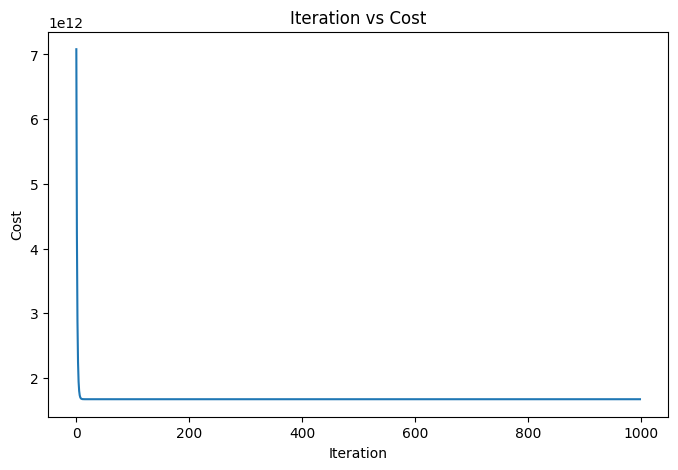

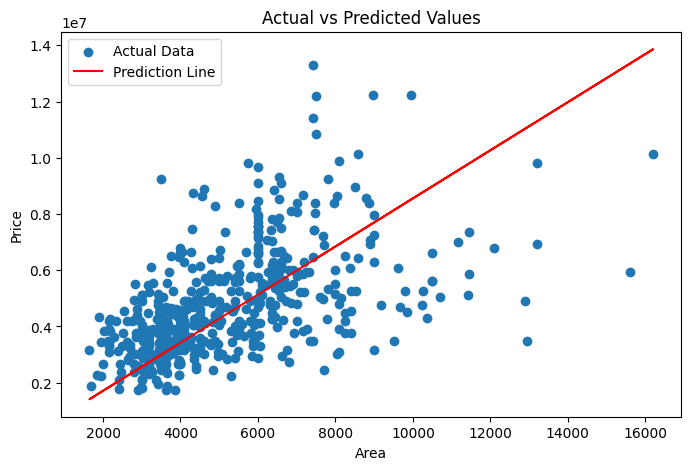

In [5]:
def gradient_decsent(X, Y, w_input, b_input, max_iter, alpha=0.0000001):

    w = w_input
    b = b_input

    cost_memo = []
    iteration = []

    for i in range(max_iter):

        dj_dw, dj_db = calculate_gradient(X, Y, w, b)

        # Update Parameters

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        cost = compute_cost(X, Y, w, b)

        cost_memo.append(cost)
        iteration.append(i)

        if i % 100 == 0:

            print(
                f"Iteration {i}: Cost = {cost:.4f}, w = {w:.4f}, b = {b:.4f}"
            )

    return w, b, cost_memo, iteration


# ==========================
# Initial Parameters
# ==========================

w_input = 0
b_input = 0

initial_cost = compute_cost(X, Y, w_input, b_input)

print("Initial Cost =", initial_cost)


# ==========================
# Train Model
# ==========================

w_final, b_final, cost_memo, iter_list =gradient_decsent(X,Y,w_input=0,b_input=0,max_iter=1000,alpha=0.00000001)



# Final Parameters


print("\nFinal Parameters")

print(f"Optimized w: {w_final:.4f}")
print(f"Optimized b: {b_final:.4f}")



# Prediction


Y_pred = w_final * X + b_final


# Iteration vs Cost Plot


plt.figure(figsize=(8,5))

plt.plot(iter_list, cost_memo)

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Iteration vs Cost")

plt.show()



# Actual vs Predicted Plot

plt.figure(figsize=(8,5))

plt.scatter(X, Y, label="Actual Data")

plt.plot(X, Y_pred, color="red", label="Prediction Line")

plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Actual vs Predicted Values")

plt.legend()

plt.show()

✔ 1000 iteration → শুধু w,b শেখে
✔ এরপর সেই w,b → সব X এর জন্য output বের করে

# **Problem 2: Student Performance Prediction**
Dataset:

Student Performance Dataset

Tasks

Predict math score using reading score. convert them to numpy array from the dataframe

Implement the MSE Cost Function manually.

Compute the gradient formulas manually.

Perform Gradient Descent for 500 iterations.

Print the cost after every 50 iterations.

Plot Cost vs Iteration.


In [6]:
df= pd.read_csv('StudentsPerformance.csv')
df


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [7]:
from matplotlib.collections import QuadMesh
x=df['reading score'].values
y=df['math score'].values

#msc cost
def compute_cost(x,y,w,b):
    m=x.shape[0]
    cost=0.0
    for i in range(m):
      pred_y=w*x[i]+b
      error=pred_y-y[i]
      cost=cost+error**2

    return cost/(2*m)

 # gradient
def gradient(x,y,w,b):
  m=x.shape[0]
  dj_dw=0.0
  dj_db=0.0
  for i in range(m):
    pred_y = w * x[i] + b
    error=pred_y - y[i]

    dj_dw = dj_dw + error*x[i]
    dj_db = dj_db + error

  return dj_dw/m,dj_db/m

def gradient_descent(x, y, w, b, alpha, iterations):

    cost_memo = []
    iteration_list = []

    for i in range(iterations):

        dj_dw, dj_db = gradient(x, y, w, b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        cost = compute_cost(x, y, w, b)

        cost_memo.append(cost)
        iteration_list.append(i)

        if i % 50== 0:
            print(f"Iteration {i}: Cost = {cost:.4f}, w = {w:.4f}, b = {b:.4f}")

    return w, b, cost_memo, iteration_list


w_final,b_final,cost_memo,iter_list=gradient_descent(x,y,w=0,b=0,alpha = 0.000001,iterations=500)





Iteration 0: Cost = 2276.1919, w = 0.0048, b = 0.0001
Iteration 50: Cost = 1394.5513, w = 0.2144, b = 0.0030
Iteration 100: Cost = 860.3862, w = 0.3776, b = 0.0053
Iteration 150: Cost = 536.7481, w = 0.5046, b = 0.0070
Iteration 200: Cost = 340.6635, w = 0.6035, b = 0.0084
Iteration 250: Cost = 221.8605, w = 0.6805, b = 0.0095
Iteration 300: Cost = 149.8805, w = 0.7404, b = 0.0103
Iteration 350: Cost = 106.2695, w = 0.7870, b = 0.0110
Iteration 400: Cost = 79.8467, w = 0.8233, b = 0.0115
Iteration 450: Cost = 63.8377, w = 0.8515, b = 0.0119


In [8]:
print(f"Final Parameters: w = {w_final:.4f}, b = {b_final:.4f}")

Final Parameters: w = 0.8731, b = 0.0122


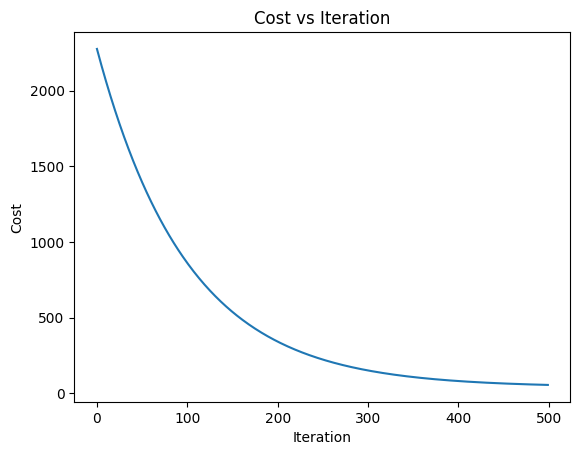

In [9]:
plt.plot(iter_list,cost_memo)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost vs Iteration')
plt.show()

🔵 X-axis (Iteration)

👉 তুমি কতবার model update করেছো (0 → 500)

Iteration 0 = শুরু
Iteration 500 = শেষ training

🔴 Y-axis (Cost)

👉 model কতটা ভুল করছে

বেশি cost = বেশি ভুল ❌
কম cost = কম ভুল ✅

🧠 এখন তোমার গ্রাফ কী বলছে?

📌 শুরুতে (Iteration 0)

Cost ≈ 2200+

মানে model খুবই ভুল করছিল

👉 line অনেক খারাপ ছিল (fit হয়নি)

📉 মাঝখানে (100–300 iteration)

Cost দ্রুত কমছে

2000 → 1000 → 500 → 200

👉 মানে model শিখছে

✔ w change হচ্ছে
✔ b change হচ্ছে
✔ line data এর দিকে যাচ্ছে

🟢 শেষে (400–500 iteration)

Cost ≈ 50–100 এর কাছে

curve flatten হয়ে যাচ্ছে

👉 মানে:

✔ improvement কমে গেছে

✔ model almost best fit এ চলে এসেছে

✔ convergence হচ্ছে

🎯 সবচেয়ে important concept
🔥 “Cost decreasing curve”

এটা দেখায়:

👉 Gradient Descent কাজ করছে
👉 Model ধীরে ধীরে error কমাচ্ছে

🧠 সহজ ভাষায়:

👉 শুরুতে model অন্ধভাবে ভুল করছিল
👉 পরে ধীরে ধীরে শিখছে
👉 শেষে almost perfect fit এ পৌঁছেছে

⚡ কেন curve smooth?

কারণ:

প্রতিটা iteration small update করে
তাই cost abrupt jump না করে gradually কমে

🎬 এক লাইনে meaning

👉 এই graph দেখায় model training সফলভাবে converge করছে (error কমছে step by step)

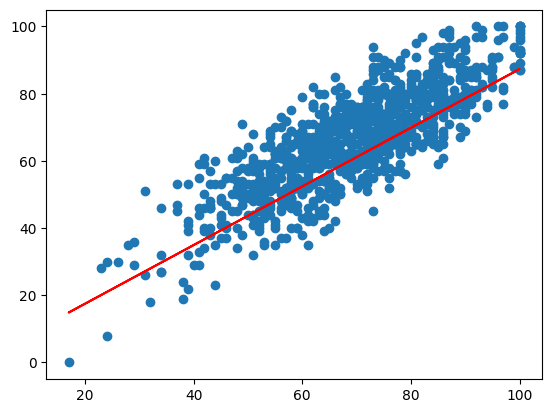

In [10]:
final_preds  = w_final * x + b_final
 # modal sturdy kore final ber kore felse already akyta specific value
plt.scatter(x,y,label='Actual Data')
plt.plot(x,final_preds,color='red',label='Prediction Line')


# **Problem 3: Insurance Charges Prediction**
Dataset:

Medical Cost Personal Dataset
Tasks

Use age as input feature.

Use charges as target.

Convert them to numpy array from the dataframe
Implement:

Cost Function

Gradient Calculation

Gradient Descent

Train for 1000 iterations.

Compare initial and final costs.

Visualize the regression line.


In [11]:
df=pd.read_csv('insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [12]:
from matplotlib._api import warn_deprecated
from os import error
x=df['age'].values
y=df['charges'].values

# cost function MSC

def compute_cost(x,y,w,b):
  m=x.shape[0]
  cost=0.0
  for i in range(m):
    prediction=w * x[i] + b
    error=prediction-y[i]
    cost=cost+error**2

  return cost/(2*m)

# gradient

def gradient(x,y,w,b):
  m=x.shape[0]
  dj_dw=0.0
  dj_db=0.0
  for i in range(m):
    prediction = w*x[i] + b
    error= prediction - y[i]
    dj_dw=dj_dw + (error*x[i])
    dj_db=dj_db + error

  return dj_dw/m,dj_db/m

#gradient decent

def gradient_decsent(x,y,w_input,b_input,max_iter,alpha=0.0000001):
  w=w_input # akto natok
  b=b_input
  cost_memo=[] # Agola alada bhabe nisi karon jeno compurte function k call korar por or cost er iteration er information akne append hoi
  iteration=[]  # ata moloto iteration soinka
  for i in range(max_iter):
    dj_dw,dj_db=gradient(x,y,w,b)    # call hoise gradient
    w=w-alpha*dj_dw
    b=b-alpha*dj_db

    cost=compute_cost(x,y,w,b)       # akne call hoise compute cost

    cost_memo.append(cost)
    iteration.append(i)

    if i%10==0:

      print(f"Iteration {i}: Cost = {cost:.4f}, w = {w:.4f}, b = {b:.4f}")
  return w,b,cost_memo,iteration


w_final,b_final,cost_memo,iter_list=gradient_decsent(x,y,w_input=0,b_input=0,max_iter=1000,alpha=0.00000001) # peramter pass korsi w_input =0


Iteration 0: Cost = 161320173.1604, w = 0.0057, b = 0.0001
Iteration 10: Cost = 161287543.0504, w = 0.0628, b = 0.0015
Iteration 20: Cost = 161254924.2633, w = 0.1199, b = 0.0028
Iteration 30: Cost = 161222316.7953, w = 0.1770, b = 0.0041
Iteration 40: Cost = 161189720.6423, w = 0.2341, b = 0.0054
Iteration 50: Cost = 161157135.8004, w = 0.2912, b = 0.0068
Iteration 60: Cost = 161124562.2658, w = 0.3482, b = 0.0081
Iteration 70: Cost = 161092000.0345, w = 0.4053, b = 0.0094
Iteration 80: Cost = 161059449.1026, w = 0.4623, b = 0.0107
Iteration 90: Cost = 161026909.4661, w = 0.5193, b = 0.0121
Iteration 100: Cost = 160994381.1212, w = 0.5763, b = 0.0134
Iteration 110: Cost = 160961864.0639, w = 0.6334, b = 0.0147
Iteration 120: Cost = 160929358.2903, w = 0.6903, b = 0.0160
Iteration 130: Cost = 160896863.7965, w = 0.7473, b = 0.0174
Iteration 140: Cost = 160864380.5786, w = 0.8043, b = 0.0187
Iteration 150: Cost = 160831908.6327, w = 0.8613, b = 0.0200
Iteration 160: Cost = 160799447.954

In [13]:
print(f'Final Parameters: w = {w_final:.4f}, b = {b_final:.4f}')

Final Parameters: w = 5.6621, b = 0.1316


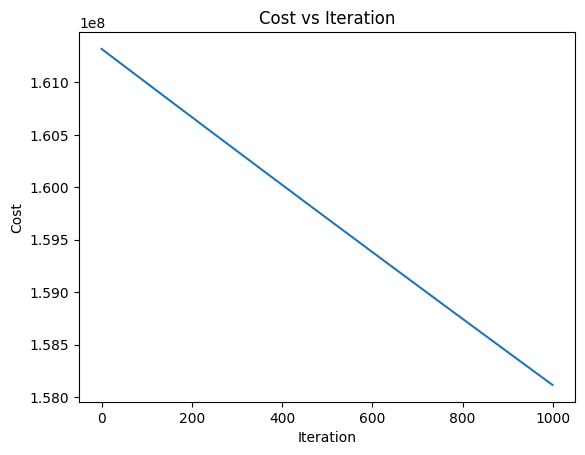

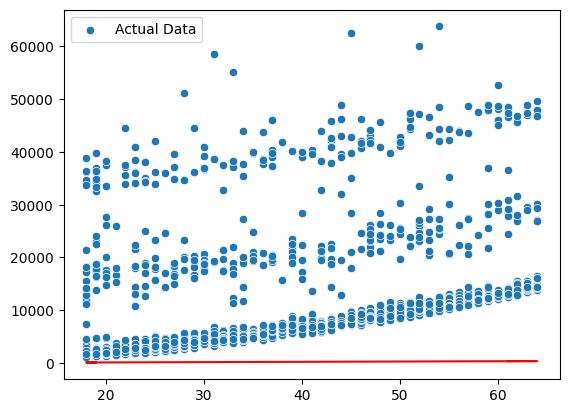

In [14]:
import seaborn as sns
plt.plot(iter_list,cost_memo)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost vs Iteration')
plt.show()
final_preds  = w_final * x + b_final
sns.scatterplot(x=x,y=y,label='Actual Data')
plt.plot(x,final_preds,color='red',label='Prediction Line')



# **Problem 4: Salary Prediction**

Dataset:

Salary Dataset

Tasks

Predict Salary from YearsExperience.

Initialize parameters randomly.

Calculate cost before training.

Apply Gradient Descent.

Plot:

Cost vs Iteration

Regression Line


In [15]:
df=pd.read_csv('Salary_Data.csv')
df

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [16]:
x=df['YearsExperience'].values
y=df['Salary'].values

def compute_cost(x,y,w,b):
  m=x.shape[0]
  cost=0.0
  for i in range(m):
    prediction=w * x[i] + b

    error=prediction-y[i]

    cost=cost+error**2

  return cost/(2*m)


def gradient(x,y,w,b):
  m=x.shape[0]
  dj_dw=0.0
  dj_db=0.0
  for i in range(m):
    prediction = w*x[i] + b
    error=prediction -y[i]
    dj_dw=dj_dw +(error* x[i])
    dj_db=dj_db + error

  return dj_dw/m,dj_db/m


def gradient_decsent(x,y,w_input,b_input,iterations,alpha):
  w=w_input
  b=b_input
  cost_memo=[]
  iteration=[]
  for i in range(iterations):
    dj_dw,dj_db=gradient(x,y,w,b)
    w=w-alpha*dj_dw
    b=b-alpha*dj_db

    cost=compute_cost(x,y,w,b)
    cost_memo.append(cost)
    iteration.append(i)

    if i%10==0:
      print(f'Iteration {i}: Cost = {cost:.4f}, w = {w:.4f}, b = {b:.4f}')
  return w,b,cost_memo,iteration

In [17]:
w_final,b_final,cost_memo,iter_list=gradient_decsent(x,y,w_input=0,b_input=0,iterations=1000,alpha=0.00000001)

Iteration 0: Cost = 3251475298.5073, w = 0.0048, b = 0.0008
Iteration 10: Cost = 3251451930.0088, w = 0.0525, b = 0.0084
Iteration 20: Cost = 3251428561.6822, w = 0.1003, b = 0.0160
Iteration 30: Cost = 3251405193.5276, w = 0.1480, b = 0.0236
Iteration 40: Cost = 3251381825.5450, w = 0.1957, b = 0.0312
Iteration 50: Cost = 3251358457.7344, w = 0.2435, b = 0.0388
Iteration 60: Cost = 3251335090.0958, w = 0.2912, b = 0.0464
Iteration 70: Cost = 3251311722.6292, w = 0.3389, b = 0.0540
Iteration 80: Cost = 3251288355.3346, w = 0.3867, b = 0.0616
Iteration 90: Cost = 3251264988.2119, w = 0.4344, b = 0.0692
Iteration 100: Cost = 3251241621.2613, w = 0.4822, b = 0.0768
Iteration 110: Cost = 3251218254.4826, w = 0.5299, b = 0.0844
Iteration 120: Cost = 3251194887.8759, w = 0.5776, b = 0.0920
Iteration 130: Cost = 3251171521.4412, w = 0.6254, b = 0.0996
Iteration 140: Cost = 3251148155.1785, w = 0.6731, b = 0.1072
Iteration 150: Cost = 3251124789.0877, w = 0.7209, b = 0.1148
Iteration 160: Cost

In [23]:
print(f'final perameters: w = {w_final:.4f}, b = {b_final:.4f}')

final perameters: w = 4.7731, b = 0.7599


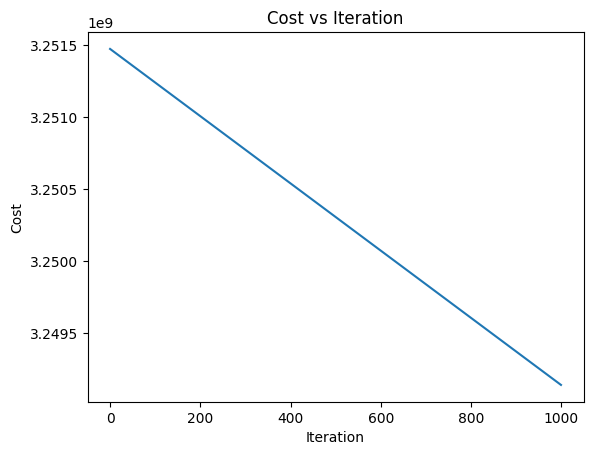

In [18]:
plt.plot(iter_list,cost_memo)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost vs Iteration')
plt.show()

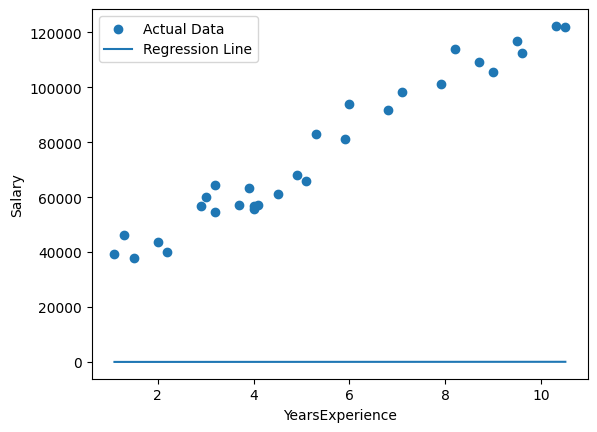

In [22]:
plt.scatter(x,y,label='Actual Data')

y_pred = w_final*x + b_final

plt.plot(x,y_pred,label='Regression Line')

plt.xlabel("YearsExperience")
plt.ylabel("Salary")

plt.legend()


plt.show()

In [ ]:
plt.